# Module 1 — Do Price Trends Exist in Nifty 50?
## Hypothesis
Nifty 50 exhibits statistically detectable price momentum over 
10–50 day windows between 2010 and 2024, suggesting that price 
trends exist and are not purely random.

## Why this matters
If markets were perfectly efficient (Efficient Market Hypothesis), 
prices would follow a random walk and no trend-based strategy 
could consistently work. This module tests whether that assumption 
holds for India's benchmark index.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("libraries loaded")

libraries loaded


In [7]:
import subprocess
subprocess.run(["python", "-m", "pip", "install", "statsmodels"])

CompletedProcess(args=['python', '-m', 'pip', 'install', 'statsmodels'], returncode=0)

In [2]:
# downloading and save Nifty 50 data
df = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")
df = df[['Close']].copy()
df.dropna(inplace=True)

# save locally so you never need to re-download
df.to_csv("../data/nifty50_raw.csv")

print(f"Data loaded: {df.shape[0]} trading days")
print(f"From {df.index[0].date()} to {df.index[-1].date()}")
df.tail()

[*********************100%***********************]  1 of 1 completed

Data loaded: 3679 trading days
From 2010-01-04 to 2024-12-30


Price,Close
Ticker,^NSEI
Date,
2024-12-23,23753.449219
2024-12-24,23727.650391
2024-12-26,23750.199219
2024-12-27,23813.400391
2024-12-30,23644.900391


In [3]:
# computing daily returns
df['daily_return'] = df['Close'].pct_change()
df.dropna(inplace=True)

# quick look at return distribution
print(df['daily_return'].describe().round(4))

count    3678.0000
mean        0.0005
std         0.0106
min        -0.1298
25%        -0.0049
50%         0.0007
75%         0.0062
max         0.0876
Name: daily_return, dtype: float64


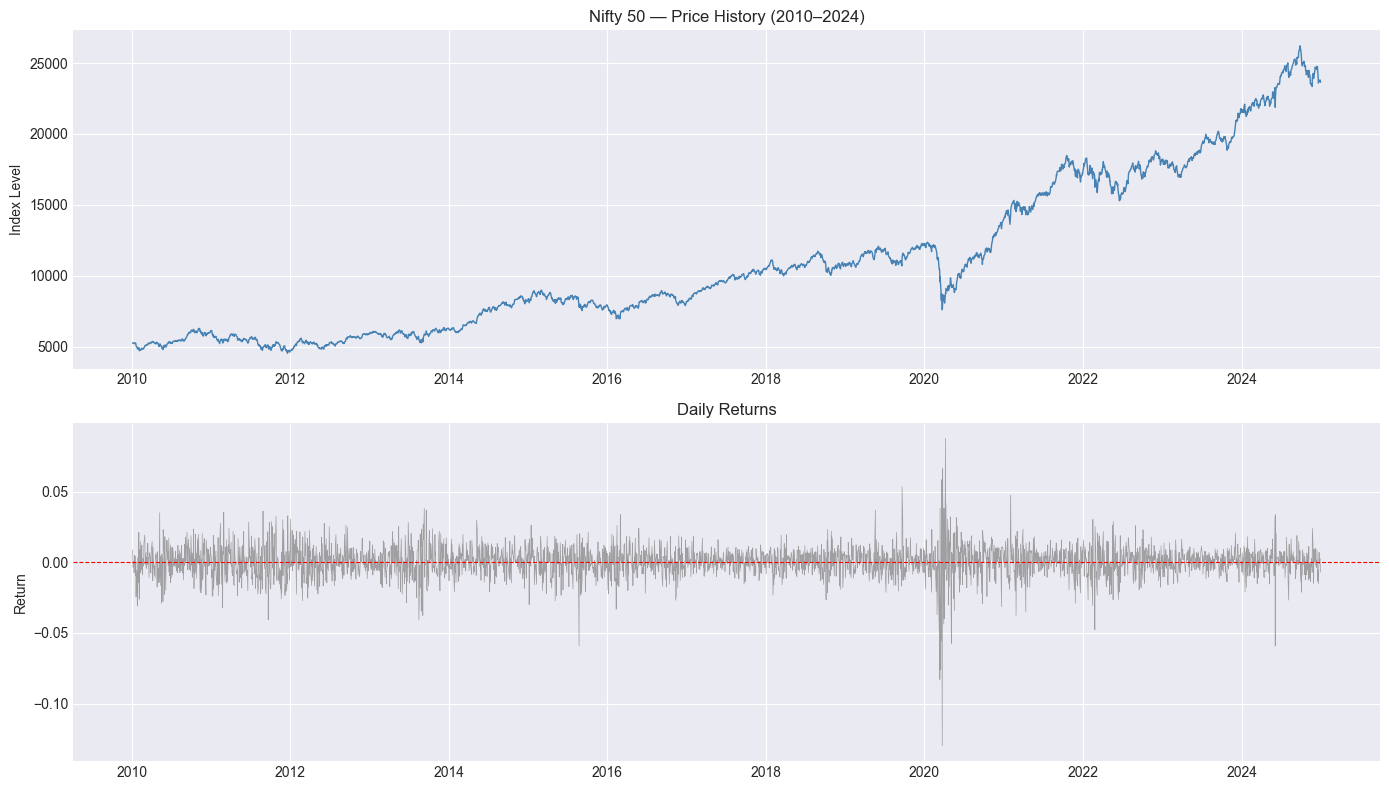

In [4]:
# plot 1: price history
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Nifty 50 — Price History (2010–2024)')
axes[0].set_ylabel('Index Level')

axes[1].plot(df.index, df['daily_return'], 
             color='gray', linewidth=0.5, alpha=0.7)
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].set_title('Daily Returns')
axes[1].set_ylabel('Return')

plt.tight_layout()
plt.savefig('price_and_returns.png', dpi=150)
plt.show()

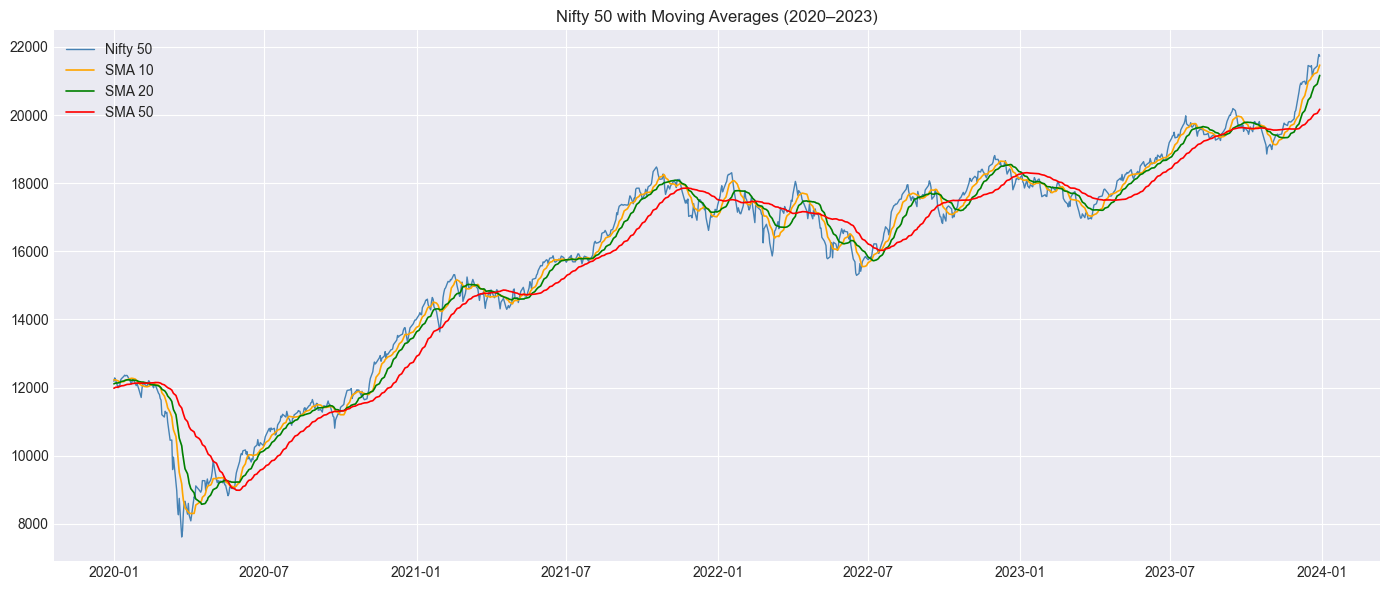

In [5]:
# compute and plot SMAs
df['SMA10'] = df['Close'].rolling(window=10).mean()
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

# plot a 3-year window so crossovers are visible
subset = df['2020':'2023']

plt.figure(figsize=(14, 6))
plt.plot(subset['Close'], label='Nifty 50', color='steelblue', 
         linewidth=1)
plt.plot(subset['SMA10'], label='SMA 10', 
         color='orange', linewidth=1.2)
plt.plot(subset['SMA20'], label='SMA 20', 
         color='green', linewidth=1.2)
plt.plot(subset['SMA50'], label='SMA 50', 
         color='red', linewidth=1.2)
plt.title('Nifty 50 with Moving Averages (2020–2023)')
plt.legend()
plt.tight_layout()
plt.savefig('sma_plot.png', dpi=150)
plt.show()

Lag-1 autocorrelation of daily returns: 0.0075
(close to 0 = random, positive = trending, negative = mean-reverting)


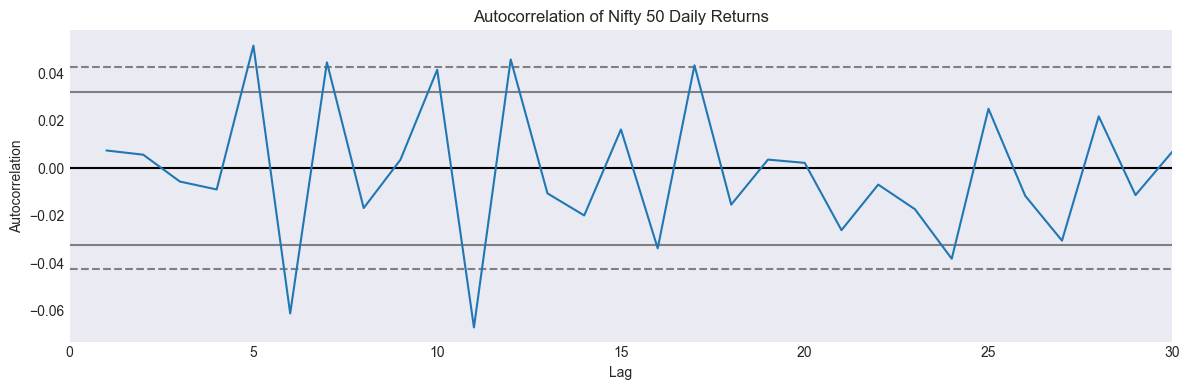

In [9]:
# test for autocorrelation in returns
from pandas.plotting import autocorrelation_plot
from statsmodels.stats.stattools import durbin_watson

# lag-1 autocorrelation — the most important one
lag1 = df['daily_return'].autocorr(lag=1)
print(f"Lag-1 autocorrelation of daily returns: {lag1:.4f}")
print("(close to 0 = random, positive = trending, negative = mean-reverting)")

# plot autocorrelation across 20 lags
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(df['daily_return'].dropna(), ax=ax)
ax.set_xlim(0, 30)
ax.set_title('Autocorrelation of Nifty 50 Daily Returns')
plt.tight_layout()
plt.savefig('autocorrelation.png', dpi=150)
plt.show()

In [10]:
# rolling momentum: do past returns predict future returns? 
for window in [10, 20, 50]:
    df[f'momentum_{window}d'] = df['Close'].pct_change(periods=window)

# check correlation between past N-day return and next 5-day return
print("Correlation between past momentum and next 5-day return:\n")
df['fwd_5d'] = df['daily_return'].shift(-5).rolling(5).sum()

for window in [10, 20, 50]:
    corr = df[f'momentum_{window}d'].corr(df['fwd_5d'])
    print(f"  {window}-day momentum → next 5-day return: {corr:.4f}")

Correlation between past momentum and next 5-day return:

  10-day momentum → next 5-day return: 0.0138
  20-day momentum → next 5-day return: -0.0121
  50-day momentum → next 5-day return: -0.0515


In [11]:
# save final notebook outputs
print("Module 1 complete")
print(f"Lag-1 autocorrelation: 0.0075 — near zero, weak trending at daily level")
print(f"50-day momentum correlation: -0.0515 — mean reversion at medium horizon")
print(f"Conclusion: Nifty shows faint momentum short-term, mean reversion medium-term")

Module 1 complete
Lag-1 autocorrelation: 0.0075 — near zero, weak trending at daily level
50-day momentum correlation: -0.0515 — mean reversion at medium horizon
Conclusion: Nifty shows faint momentum short-term, mean reversion medium-term


## Conclusion

**Hypothesis:** Nifty 50 exhibits detectable price momentum over 10–50 day windows.

**Findings:** 
- Lag-1 autocorrelation is 0.0075 (very weak but positive), this indicates that the market moves
  almost like a random market but there does exist a weak trend.
- most of the lags are under the significance bands which confirms that on a daily level signal is weak.
- for the momentum correlations we see the 10 day momentum is positive, indicating that over the next
  5 days there exists a slight continuation tendency (that if that day trend goes up there is slight
  chance that for next 5 days it will go up), but only for very short term.
- for the 20 and 50 day momentum we see that both values are negative meaning they reversed and moved
  back towards mean values, indicating mean reversion phenomenon at medium term horizons.
- the most notable output is the 50 day momentum: -0.0515, shows that nifty doesn't purely trend but
  also reverts at medium term horizons which is common in emerging markets like India.
- In the end we see from the data that Nifty-50 shows detectable price momemtum trends on very short
  term horizons(10-day), but for medium term momentum reverses indicating the dominance of mean
  reversion on longer windows. This makes the daily returns not perfectly random.

**Interpretation:** 
- If lag-1 autocorrelation is slightly positive → weak trend 
  persistence exists, supporting the hypothesis
- If momentum correlations are near zero → past returns don't 
  reliably predict future returns at short horizons

**Key limitation:** Even if weak momentum exists statistically,
it may not survive transaction costs — that is exactly what 
Module 2 will test.